In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
!cp -r /content/gdrive/My\ Drive/mask-rcnn ./

In [ ]:
%cd mask-rcnn

/content/mask-rcnn


In [ ]:
!python mask_rcnn.py --mask-rcnn mask-rcnn-coco --image images/example_01.jpg

/usr/local/lib/python3.6/dist-packages/IPython/utils/traitlets.py:5: UserWarning: IPython.utils.traitlets has moved to a top-level traitlets package.
  warn("IPython.utils.traitlets has moved to a top-level traitlets package.")
[INFO] loading Mask R-CNN from disk...
[INFO] Mask R-CNN took 6.656946 seconds
[INFO] boxes shape: (1, 1, 100, 7)
[INFO] masks shape: (100, 90, 15, 15)
Traceback (most recent call last):
  File "mask_rcnn.py", line 140, in <module>
    cv2_imshow(clone)
  File "/usr/local/lib/python3.6/dist-packages/google/colab/patches/__init__.py", line 29, in cv2_imshow
    display.display(PIL.Image.fromarray(a))
AttributeError: module 'PIL' has no attribute 'Image'


[INFO] loading Mask R-CNN from disk...
[INFO] Mask R-CNN took 5.327322 seconds
[INFO] boxes shape: (1, 1, 100, 7)
[INFO] masks shape: (100, 90, 15, 15)


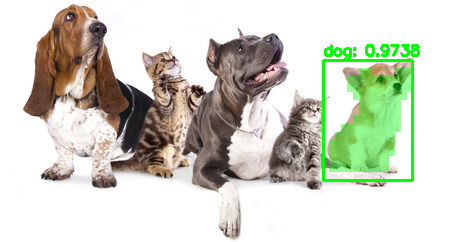

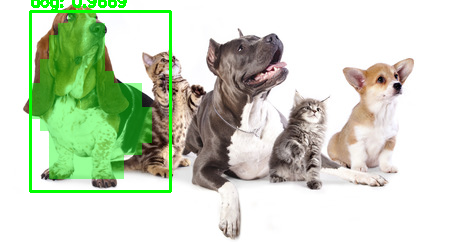

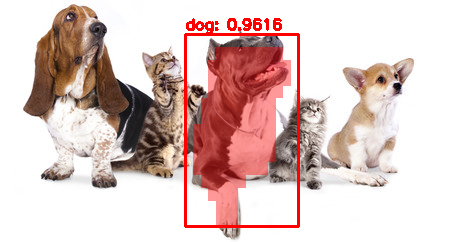

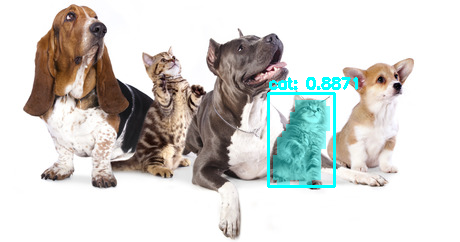

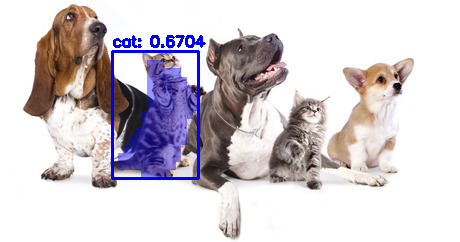

In [ ]:
# USAGE
# python mask_rcnn.py --mask-rcnn mask-rcnn-coco --image images/example_01.jpg
# python mask_rcnn.py --mask-rcnn mask-rcnn-coco --image images/example_03.jpg --visualize 1

# import the necessary packages
import numpy as np
import argparse
import random
import time
import cv2
import os
from google.colab.patches import cv2_imshow

# construct the argument parse and parse the arguments
'''
ap = argparse.ArgumentParser()
ap.add_argument("-i", "--image", required=True,
	help="path to input image")
ap.add_argument("-m", "--mask-rcnn", required=True,
	help="base path to mask-rcnn directory")
ap.add_argument("-v", "--visualize", type=int, default=0,
	help="whether or not we are going to visualize each instance")
ap.add_argument("-c", "--confidence", type=float, default=0.5,
	help="minimum probability to filter weak detections")
ap.add_argument("-t", "--threshold", type=float, default=0.3,
	help="minimum threshold for pixel-wise mask segmentation")

args = vars(ap.parse_args())
'''

args = {'image': 'images/dog_cat_11.jpg', 'mask_rcnn': 'mask-rcnn-coco', 'visualize': 0, 'confidence': 0.5, 'threshold': 0.3}

# load the COCO class labels our Mask R-CNN was trained on
labelsPath = os.path.sep.join([args["mask_rcnn"],
	"object_detection_classes_coco.txt"])
LABELS = open(labelsPath).read().strip().split("\n")

# load the set of colors that will be used when visualizing a given
# instance segmentation
colorsPath = os.path.sep.join([args["mask_rcnn"], "colors.txt"])
COLORS = open(colorsPath).read().strip().split("\n")
COLORS = [np.array(c.split(",")).astype("int") for c in COLORS]
COLORS = np.array(COLORS, dtype="uint8")

# derive the paths to the Mask R-CNN weights and model configuration
weightsPath = os.path.sep.join([args["mask_rcnn"],
	"frozen_inference_graph.pb"])
configPath = os.path.sep.join([args["mask_rcnn"],
	"mask_rcnn_inception_v2_coco_2018_01_28.pbtxt"])

# load our Mask R-CNN trained on the COCO dataset (90 classes)
# from disk
print("[INFO] loading Mask R-CNN from disk...")
net = cv2.dnn.readNetFromTensorflow(weightsPath, configPath)

# load our input image and grab its spatial dimensions
image = cv2.imread(args["image"])
(H, W) = image.shape[:2]

# construct a blob from the input image and then perform a forward
# pass of the Mask R-CNN, giving us (1) the bounding box  coordinates
# of the objects in the image along with (2) the pixel-wise segmentation
# for each specific object
blob = cv2.dnn.blobFromImage(image, swapRB=True, crop=False)
net.setInput(blob)
start = time.time()
(boxes, masks) = net.forward(["detection_out_final", "detection_masks"])
end = time.time()

# show timing information and volume information on Mask R-CNN
print("[INFO] Mask R-CNN took {:.6f} seconds".format(end - start))
print("[INFO] boxes shape: {}".format(boxes.shape))
print("[INFO] masks shape: {}".format(masks.shape))

# loop over the number of detected objects
for i in range(0, boxes.shape[2]):
    # extract the class ID of the detection along with the confidence
    # (i.e., probability) associated with the prediction
    classID = int(boxes[0, 0, i, 1])
    confidence = boxes[0, 0, i, 2]

    # filter out weak predictions by ensuring the detected probability
    # is greater than the minimum probability
    if confidence > args["confidence"]:
        # clone our original image so we can draw on it
        clone = image.copy()

        # scale the bounding box coordinates back relative to the
        # size of the image and then compute the width and the height
        # of the bounding box
        box = boxes[0, 0, i, 3:7] * np.array([W, H, W, H])
        (startX, startY, endX, endY) = box.astype("int")
        boxW = endX - startX
        boxH = endY - startY

        # extract the pixel-wise segmentation for the object, resize
        # the mask such that it's the same dimensions of the bounding
        # box, and then finally threshold to create a *binary* mask
        mask = masks[i, classID]
        mask = cv2.resize(mask, (boxW, boxH),
        	interpolation=cv2.INTER_NEAREST)
        mask = (mask > args["threshold"])

        # extract the ROI of the image
        roi = clone[startY:endY, startX:endX]

        # check to see if are going to visualize how to extract the
        # masked region itself
        if args["visualize"] > 0:
            # convert the mask from a boolean to an integer mask with
            # to values: 0 or 255, then apply the mask
            visMask = (mask * 255).astype("uint8")
            instance = cv2.bitwise_and(roi, roi, mask=visMask)
            # show the extracted ROI, the mask, along with the
            # segmented instance
            #cv2.imshow("ROI", roi)
            #cv2.imshow("Mask", visMask)
            #cv2.imshow("Segmented", instance)
            cv2_imshow(roi)
            cv2_imshow(visMask)
            cv2_imshow(instance)

        # now, extract *only* the masked region of the ROI by passing
        # in the boolean mask array as our slice condition
        roi = roi[mask]

        # randomly select a color that will be used to visualize this
        # particular instance segmentation then create a transparent
        # overlay by blending the randomly selected color with the ROI
        color = random.choice(COLORS)
        blended = ((0.4 * color) + (0.6 * roi)).astype("uint8")

        # store the blended ROI in the original image
        clone[startY:endY, startX:endX][mask] = blended

        # draw the bounding box of the instance on the image
        color = [int(c) for c in color]
        cv2.rectangle(clone, (startX, startY), (endX, endY), color, 2)

        # draw the predicted label and associated probability of the
        # instance segmentation on the image
        text = "{}: {:.4f}".format(LABELS[classID], confidence)
        cv2.putText(clone, text, (startX, startY - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # show the output image
        #cv2.imshow("Output", clone)
        cv2_imshow(clone)
        cv2.waitKey(0)
